In [5]:
%pip install matplotlib scikit-learn torch tqdm

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Imports
import os, time, torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchinfo import summary
from sklearn.metrics import f1_score, accuracy_score, classification_report
import pandas as pd
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [7]:
import kagglehub
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
basePath = itsahmad_indoor_scenes_cvpr_2019_path

rootDir = basePath + "/indoorCVPR_09/Images"

In [8]:
allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                allData.append((os.path.join(labelDir, file), label))

trainData, tempData = train_test_split(allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42)
valData, testData = train_test_split(tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42)

labelNames = sorted(set(label for _, label in allData))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}

print(labelNames)
print(f"Train: {len(trainData)}, Val: {len(valData)}, Test: {len(testData)}")

['airport_inside', 'artstudio', 'auditorium', 'bakery', 'bar', 'bathroom', 'bedroom', 'bookstore', 'bowling', 'buffet', 'casino', 'children_room', 'church_inside', 'classroom', 'cloister', 'closet', 'clothingstore', 'computerroom', 'concert_hall', 'corridor', 'deli', 'dentaloffice', 'dining_room', 'elevator', 'fastfood_restaurant', 'florist', 'gameroom', 'garage', 'greenhouse', 'grocerystore', 'gym', 'hairsalon', 'hospitalroom', 'inside_bus', 'inside_subway', 'jewelleryshop', 'kindergarden', 'kitchen', 'laboratorywet', 'laundromat', 'library', 'livingroom', 'lobby', 'locker_room', 'mall', 'meeting_room', 'movietheater', 'museum', 'nursery', 'office', 'operating_room', 'pantry', 'poolinside', 'prisoncell', 'restaurant', 'restaurant_kitchen', 'shoeshop', 'stairscase', 'studiomusic', 'subway', 'toystore', 'trainstation', 'tv_studio', 'videostore', 'waitingroom', 'warehouse', 'winecellar']
Train: 12496, Val: 1562, Test: 1562


In [9]:
# Dataset + Transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.2),
    transforms.RandomAffine(15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class SceneDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        image = self.transform(image)
        return image, labelToIndex[label]

    def __len__(self):
        return len(self.data)

trainLoader = DataLoader(SceneDataset(trainData, trainTransform), batch_size=64, shuffle=True)
valLoader = DataLoader(SceneDataset(valData, transform), batch_size=64)
testLoader = DataLoader(SceneDataset(testData, transform), batch_size=64)


In [10]:
# model 1
class HybridEfficientCNN_MIT67(nn.Module):
    def __init__(self, num_classes=67):
        super(HybridEfficientCNN_MIT67, self).__init__()

        self.features = nn.Sequential(
            #Block 1
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            #Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            #Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            #SE Attention block
            SEBlock(256),

            #Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# SE Block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        se = self.pool(x).view(b, c)
        se = self.fc(se).view(b, c, 1, 1)
        return x * se
    
model1 = HybridEfficientCNN_MIT67().to(device)
summary(model1, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
HybridEfficientCNN_MIT67                 [1, 67]                   --
├─Sequential: 1-1                        [1, 512, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         4,864
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-5                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-6                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-7                       [1, 128, 112, 112]        147,584
│    └─BatchNorm2d: 2-8                  [1, 128, 112, 112]        256
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          295,

In [11]:
# model 2

#Dense Layer
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        return torch.cat([x, out], 1) 

#Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

#Transition Layer
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.layer(x)

#CompleteDenseNet
class DenseNetLikeSceneClassifier(nn.Module):
    def __init__(self, growth_rate=32, block_layers=[6, 12, 24, 16], num_classes=67):
        super(DenseNetLikeSceneClassifier, self).__init__()

        #Init Conv Layer
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),  
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)  
        )

        # Dense Blocks + Transitions
        self.features = nn.Sequential()
        num_channels = 64
        for i, num_layers in enumerate(block_layers):
            block = DenseBlock(num_layers, num_channels, growth_rate)
            self.features.add_module(f'denseblock{i+1}', block)
            num_channels = num_channels + num_layers * growth_rate
            if i != len(block_layers) - 1:  
                trans = TransitionLayer(num_channels, num_channels // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_channels = num_channels // 2

        #Final batch norm
        self.bn_final = nn.BatchNorm2d(num_channels)

        #Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(num_channels, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.bn_final(x)
        x = self.classifier(x)
        return x
    
model2 = DenseNetLikeSceneClassifier().to(device)

summary(model2, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
DenseNetLikeSceneClassifier                   [1, 67]                   --
├─Sequential: 1-1                             [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
├─Sequential: 1-2                             [1, 1024, 7, 7]           --
│    └─DenseBlock: 2-5                        [1, 256, 56, 56]          --
│    │    └─Sequential: 3-1                   [1, 256, 56, 56]          250,560
│    └─TransitionLayer: 2-6                   [1, 128, 28, 28]          --
│    │    └─Sequential: 3-2                   [1, 128, 28, 28]          33,280
│    └─DenseBlock: 2-7                        [1, 512, 28, 28]          --
│    │ 

In [12]:
# model 3
class MiniEfficientNet(nn.Module):
    def __init__(self, num_classes=67):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.SiLU()
        )

        def MBConv(in_c, out_c, expand=6, stride=1):
            hidden = in_c * expand
            return nn.Sequential(
                nn.Conv2d(in_c, hidden, 1, bias=False), nn.BatchNorm2d(hidden), nn.SiLU(),
                nn.Conv2d(hidden, hidden, 3, stride=stride, padding=1, groups=hidden, bias=False),
                nn.BatchNorm2d(hidden), nn.SiLU(),
                SEBlock(hidden),
                nn.Conv2d(hidden, out_c, 1, bias=False), nn.BatchNorm2d(out_c)
            )

        self.blocks = nn.Sequential(
            MBConv(32, 16, expand=1),
            MBConv(16, 24, stride=2),
            MBConv(24, 40, stride=2),
            MBConv(40, 80, stride=2),
            MBConv(80, 112),
            MBConv(112, 192, stride=2),
            MBConv(192, 320)
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False), nn.BatchNorm2d(1280), nn.SiLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Flatten(),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return self.classifier(x)

model3 = MiniEfficientNet().to(device)
summary(model3, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
MiniEfficientNet                              [1, 67]                   --
├─Sequential: 1-1                             [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                            [1, 32, 112, 112]         864
│    └─BatchNorm2d: 2-2                       [1, 32, 112, 112]         64
│    └─SiLU: 2-3                              [1, 32, 112, 112]         --
├─Sequential: 1-2                             [1, 320, 7, 7]            --
│    └─Sequential: 2-4                        [1, 16, 112, 112]         --
│    │    └─Conv2d: 3-1                       [1, 32, 112, 112]         1,024
│    │    └─BatchNorm2d: 3-2                  [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                         [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-4                       [1, 32, 112, 112]         288
│    │    └─BatchNorm2d: 3-5                  [1, 32, 112, 112]         64
│    │    └─SiL

In [13]:
# model 4
class FosNet(nn.Module):
    def __init__(self, num_classes=67):
        super(FosNet, self).__init__()

        # Block 1: Low-level features
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Input: [3, 224, 224] → [32, 224, 224]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → [32, 112, 112]
        )

        # Block 2: Mid-level features
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → [64, 112, 112]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → [64, 56, 56]
        )

        # Block 3: High-level features
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# → [128, 56, 56]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → [128, 28, 28]
        )

        # Block 4: Deeper abstraction
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# → [256, 28, 28]
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)                               # → [256, 14, 14]
        )

        # Block 5: Final feature encoding
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),# → [512, 14, 14]
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)                       # → [512, 1, 1]
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),                                  # → [512]
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)                   # → [67]
        )

    def forward(self, x):
        x = self.block1(x)  # [B, 3, 224, 224] → [B, 32, 112, 112]
        x = self.block2(x)  # → [B, 64, 56, 56]
        x = self.block3(x)  # → [B, 128, 28, 28]
        x = self.block4(x)  # → [B, 256, 14, 14]
        x = self.block5(x)  # → [B, 512, 1, 1]
        x = self.classifier(x)
        return x

model4 = FosNet().to(device)
summary(model4, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
FosNet                                   [1, 67]                   --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 224, 224]         64
│    └─ReLU: 2-3                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 64, 112, 112]         18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 112, 112]         128
│    └─ReLU: 2-7                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-8                    [1, 64, 56, 56]           --
├─Sequential: 1-3                        [1, 128, 28, 28]          --
│    └─Conv2d: 2-9                       [1, 128, 56, 56]          73,856
│    

In [14]:
# ensemble model 1 efficient net
model_ensemble_effnet =  MiniEfficientNet().to(device)


In [15]:
# ensemble model 2 foxnet
model_ensemble_fosnet = FosNet().to(device)

model_ensemble_densenet = DenseNetLikeSceneClassifier().to(device)


In [16]:
# # Dummy model classes (replace with your actual classes)
# # from my_models import model1, model2, model3, model4, model_ensemble_effnet, model_ensemble_fosnet  # Replace with your model classes

# # Dataloader and labels (assumed defined)
# # valLoader, labelToIndex

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# num_classes = 67
# idx_to_label = {idx: label for label, idx in labelToIndex.items()}
# label_names = [idx_to_label[i] for i in range(num_classes)]

# # Define your models and corresponding files
# models_info = [
#     {"name": "HybridCNN", "class": model1, "path": "project_HybridCNNSE_sarayusi_vishalim.pth"},
#     {"name": "DenseNet",       "class": model2, "path": "project_DenseNet_sarayusi_vishalim.pth"},
#     {"name": "EfficientNet",       "class": model3, "path": "project_sarayusi_vishalim_efficientnet_student.pth"},
#     {"name": "FOSNet",       "class": model4, "path": "project_sarayusi_vishalim_fosnet_student.pth"},
#     {"name": "Ensemble EfficientNet",     "class": model_ensemble_effnet, "path": "project_sarayusi_vishalim_ensemble_effnet.pth"},
#     {"name": "Ensemble FOSNet",     "class": model_ensemble_fosnet, "path": "project_sarayusi_vishalim_ensemble_fosnet.pth"},
# ]



In [17]:
# def evaluate_model(model, dataloader):
#     model.eval()
#     y_true = []
#     y_pred = []

#     with torch.no_grad():
#         for images, labels in tqdm(dataloader, desc="Evaluating", leave=False):
#             images = images.to(device)
#             labels = labels.to(device)

#             outputs = model(images)
#             preds = torch.argmax(outputs, dim=1)

#             y_true.extend(labels.cpu().numpy())
#             y_pred.extend(preds.cpu().numpy())

#     acc = accuracy_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred, average='weighted')
#     return acc, f1

# # models_info = [
# #     {"name": "HybridCNN", "class": model1, "path": "project_HybridCNNSE_sarayusi_vishalim.pth"},
# #     {"name": "DenseNet",       "class": model2, "path": "project_DenseNet_sarayusi_vishalim.pth"},
# #     {"name": "EfficientNet",       "class": model3, "path": "project_sarayusi_vishalim_efficientnet_student.pth"},
# #     {"name": "FOSNet",       "class": model4, "path": "project_sarayusi_vishalim_fosnet_student.pth"},
# #     {"name": "Ensemble EfficientNet",     "class": model_ensemble_effnet, "path": "project_sarayusi_vishalim_ensemble_effnet.pth"},
# #     {"name": "Ensemble FOSNet",     "class": model_ensemble_fosnet, "path": "project_sarayusi_vishalim_ensemble_fosnet.pth"},
# # ]
# # List of model configurations
# models_info = [
#     {
#         "name": "HybridEfficientCNN",
#         "class": lambda: HybridEfficientCNN_MIT67(num_classes=num_classes),
#         "path": "project_HybridCNNSE_sarayusi_vishalim.pth"
#     },
#     {
#         "name": "DenseNetLike",
#         "class": lambda: DenseNetLikeSceneClassifier(num_classes=num_classes),
#         "path": "project_DenseNet_sarayusi_vishalim.pth"
#     },
#     {
#         "name": "MiniEfficientNet",
#         "class": lambda: MiniEfficientNet(num_classes=num_classes),
#         "path": "project_sarayusi_vishalim_efficientnet_student.pth"
#     },
#     {
#         "name": "FosNet",
#         "class": lambda: FosNet(num_classes=num_classes),
#         "path": "project_sarayusi_vishalim_fosnet_student.pth"
#     },
#     {
#         "name": "Ensemble MiniEfficientNet",
#         "class": lambda: FosNet(num_classes=num_classes),
#         "path": "project_sarayusi_vishalim_ensemble_effnet.pth"
#     },
#     {
#         "name": "Ensemble FosNet",
#         "class": lambda: FosNet(num_classes=num_classes),
#         "path": "project_sarayusi_vishalim_ensemble_fosnet.pth"
#     }
# ]

# # Collect evaluation results
# accuracies = []
# f1_scores = []
# model_names = []

# for model_info in models_info:
#     model = model_info["class"]().to(device)
#     model.load_state_dict(torch.load(model_info["path"], map_location=device))
#     acc, f1 = evaluate_model(model, valLoader)
#     accuracies.append(acc)
#     f1_scores.append(f1)
#     model_names.append(model_info["name"])
#     print(f"{model_info['name']} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

# # ========== Plotting ========== #

# x = range(len(model_names))

# plt.figure(figsize=(10, 5))

# # Accuracy
# plt.subplot(1, 2, 1)
# plt.bar(x, accuracies, color='skyblue')
# plt.xticks(x, model_names, rotation=15)
# plt.ylim(0, 1)
# plt.title("Accuracy")
# plt.ylabel("Score")

# # F1 Score
# plt.subplot(1, 2, 2)
# plt.bar(x, f1_scores, color='salmon')
# plt.xticks(x, model_names, rotation=15)
# plt.ylim(0, 1)
# plt.title("F1 Score")
# plt.ylabel("Score")

# plt.tight_layout()
# plt.show()

In [28]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    return acc, f1

# models_info = [
#     {"name": "HybridCNN", "class": model1, "path": "project_HybridCNNSE_sarayusi_vishalim.pth"},
#     {"name": "DenseNet",       "class": model2, "path": "project_DenseNet_sarayusi_vishalim.pth"},
#     {"name": "EfficientNet",       "class": model3, "path": "project_sarayusi_vishalim_efficientnet_student.pth"},
#     {"name": "FOSNet",       "class": model4, "path": "project_sarayusi_vishalim_fosnet_student.pth"},
#     {"name": "Ensemble EfficientNet",     "class": model_ensemble_effnet, "path": "project_sarayusi_vishalim_ensemble_effnet.pth"},
#     {"name": "Ensemble FOSNet",     "class": model_ensemble_fosnet, "path": "project_sarayusi_vishalim_ensemble_fosnet.pth"},
# ]
# List of model configurations
num_classes = 67
models_info = [
    {
        "name": "HybridEfficientCNN",
        "class": lambda: HybridEfficientCNN_MIT67(num_classes=num_classes),
        "path": "project_HybridCNNSE_sarayusi_vishalim.pth"
    },
    {
        "name": "DenseNetLike",
        "class": lambda: DenseNetLikeSceneClassifier(num_classes=num_classes),
        "path": "project_DenseNet_sarayusi_vishalim.pth"
    },
    {
        "name": "MiniEfficientNet",
        "class": lambda: MiniEfficientNet(num_classes=num_classes),
        "path": "project_sarayusi_vishalim_efficientnet_student.pth"
    },
    {
        "name": "FosNet",
        "class": lambda: FosNet(num_classes=num_classes),
        "path": "project_sarayusi_vishalim_fosnet_student.pth"
    },
    {
        "name": "Ensemble MiniEfficientNet",
        "class": lambda: MiniEfficientNet(num_classes=num_classes),
        "path": "project_sarayusi_vishalim_ensemble_effnet.pth"
    },
    {
        "name": "Ensemble FosNet",
        "class": lambda: FosNet(num_classes=num_classes),
        "path": "project_sarayusi_vishalim_ensemble_fosnet.pth"
    }
]

# Collect evaluation results
accuracies = []
f1_scores = []
model_names = []

for model_info in models_info:
    model = model_info["class"]().to(device)
    model.load_state_dict(torch.load(model_info["path"], map_location=device))
    acc, f1 = evaluate_model(model, valLoader)
    accuracies.append(acc)
    f1_scores.append(f1)
    model_names.append(model_info["name"])
    print(f"{model_info['name']} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

HybridEfficientCNN - Accuracy: 0.5896, F1 Score: 0.5628


DenseNetLike - Accuracy: 0.8067, F1 Score: 0.8044


MiniEfficientNet - Accuracy: 0.7586, F1 Score: 0.7538


FosNet - Accuracy: 0.5230, F1 Score: 0.4799


Ensemble MiniEfficientNet - Accuracy: 0.7586, F1 Score: 0.7538


Ensemble FosNet - Accuracy: 0.5230, F1 Score: 0.4799


In [19]:
from sklearn.metrics import classification_report

def evaluate_model_verbose(model, dataloader, model_name):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc=f"Evaluating {model_name}", leave=False):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # report = classification_report(y_true, y_pred, target_names=labelNames, digits=2)
    report = classification_report(y_true, y_pred, target_names=labelNames, digits=2, output_dict=True, zero_division=0)

    # print(f"\n📊 Classification Report for {model_name}:\n")
    # print(report)
    return report
models_result = {} 
for model_info in models_info:
    # model = model_info["class"]().to(device)
    # model.load_state_dict(torch.load(model_info["path"], map_location=device))
    # models_result[model_info['name']] = evaluate_model_verbose(model, valLoader, model_info["name"])
    model = model_info["class"]().to(device)
    model.load_state_dict(torch.load(model_info["path"], map_location=device))
    report = evaluate_model_verbose(model, valLoader, model_info["name"])
    models_result[model_info["name"]] = report

In [20]:

def weighted_soft_ensemble(imgs, model1, model2, model3,w1=0.7, w2=0.3, w3=0.4):
    with torch.no_grad():
        out1 = F.softmax(model1(imgs), dim=1)
        out2 = F.softmax(model2(imgs), dim=1)
        out3 = F.softmax(model3(imgs), dim=1)
        combined = (w1 * out1 + w2 * out2 + w3 * out3) / (w1 + w2 + w3)
        return combined
    
def evaluate_weighted_ensemble(model1, model2,model3, dataloader, label_names, w1=0.4, w2=0.2, w3=0.4):
    all_preds = []
    all_labels = []

    for imgs, labels in tqdm(dataloader, desc="Evaluating Weighted Ensemble"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = weighted_soft_ensemble(imgs, model1, model2, model3, w1=w1, w2=w2, w3=w3)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # print("\nWeighted Soft Voting Ensemble Classification Report:")
    # report = classification_report(all_labels, all_preds, target_names=label_names)
    report = classification_report(all_labels, all_preds, target_names=label_names, digits=2, output_dict=True, zero_division=0)

    # print()
    return report

model_ensemble_effnet.load_state_dict(torch.load("project_sarayusi_vishalim_efficientnet_student.pth", map_location=device))
model_ensemble_fosnet.load_state_dict(torch.load("project_sarayusi_vishalim_fosnet_student.pth", map_location=device))
model_ensemble_densenet.load_state_dict(torch.load("project_DenseNet_sarayusi_vishalim.pth", map_location=device))

report = evaluate_weighted_ensemble(model_ensemble_effnet, model_ensemble_fosnet, model_ensemble_densenet,valLoader, labelNames, w1=0.4, w2=0.2, w3=0.4)
print(report)
models_result["Ensemble - EfficientNet + FOSNet + DenseNet"] = report


Evaluating Weighted Ensemble: 100%|██████████| 25/25 [02:46<00:00,  6.67s/it]

{'airport_inside': {'precision': 0.8333333333333334, 'recall': 0.6557377049180327, 'f1-score': 0.7339449541284404, 'support': 61.0}, 'artstudio': {'precision': 0.8461538461538461, 'recall': 0.7857142857142857, 'f1-score': 0.8148148148148148, 'support': 14.0}, 'auditorium': {'precision': 0.8, 'recall': 0.8888888888888888, 'f1-score': 0.8421052631578947, 'support': 18.0}, 'bakery': {'precision': 0.7837837837837838, 'recall': 0.725, 'f1-score': 0.7532467532467533, 'support': 40.0}, 'bar': {'precision': 0.7678571428571429, 'recall': 0.7166666666666667, 'f1-score': 0.7413793103448276, 'support': 60.0}, 'bathroom': {'precision': 0.75, 'recall': 0.7894736842105263, 'f1-score': 0.7692307692307693, 'support': 19.0}, 'bedroom': {'precision': 0.7627118644067796, 'recall': 0.6818181818181818, 'f1-score': 0.72, 'support': 66.0}, 'bookstore': {'precision': 0.9333333333333333, 'recall': 0.7368421052631579, 'f1-score': 0.8235294117647058, 'support': 38.0}, 'bowling': {'precision': 0.8636363636363636, 

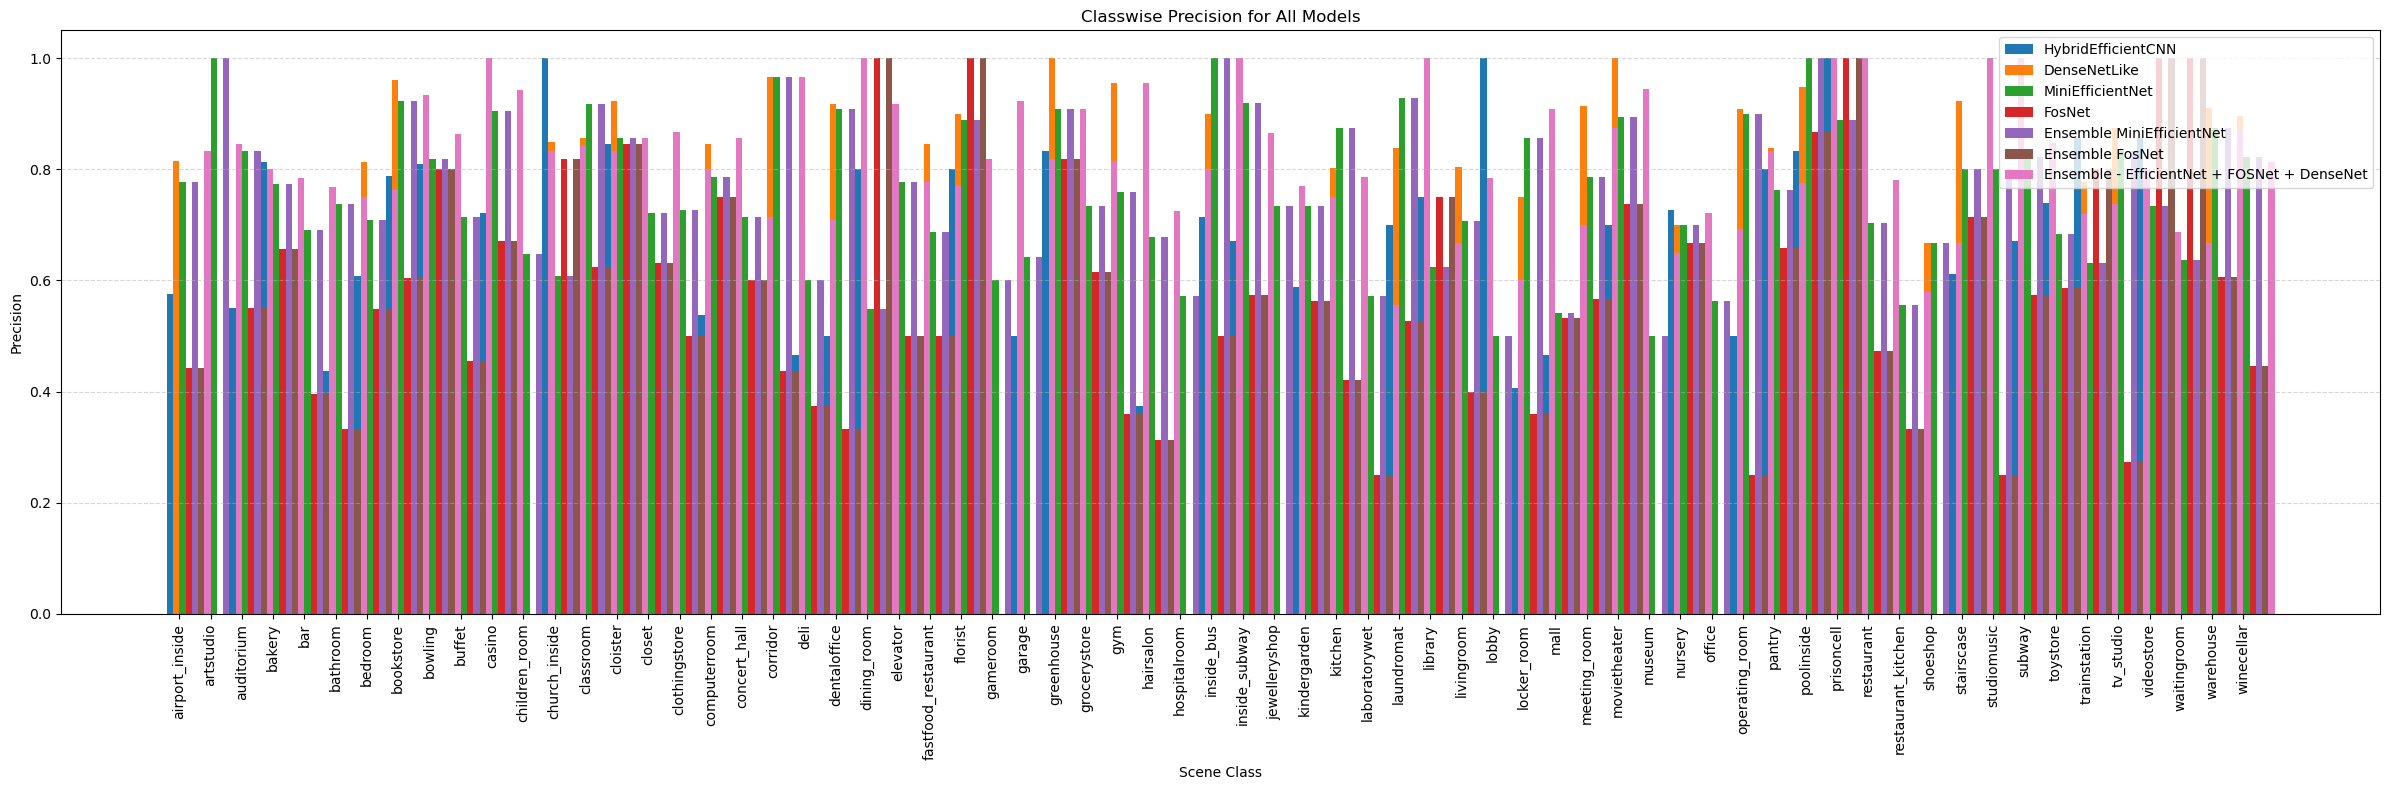

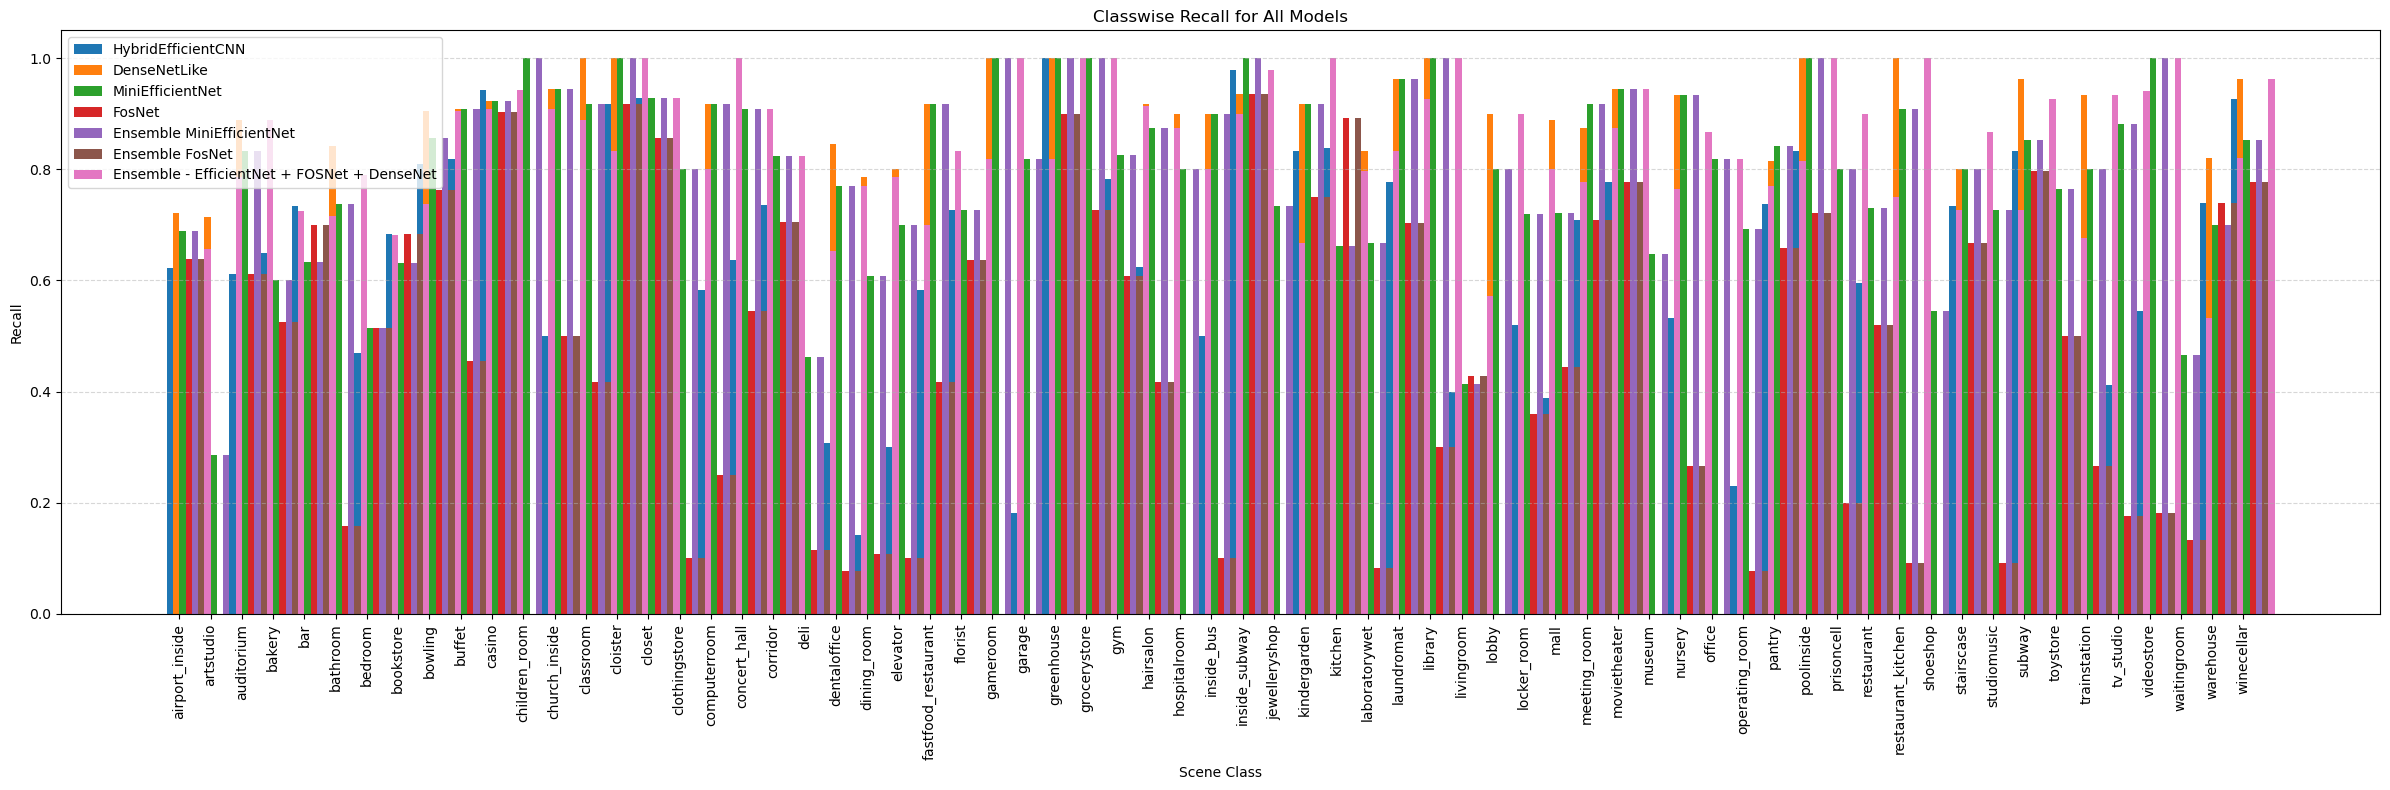

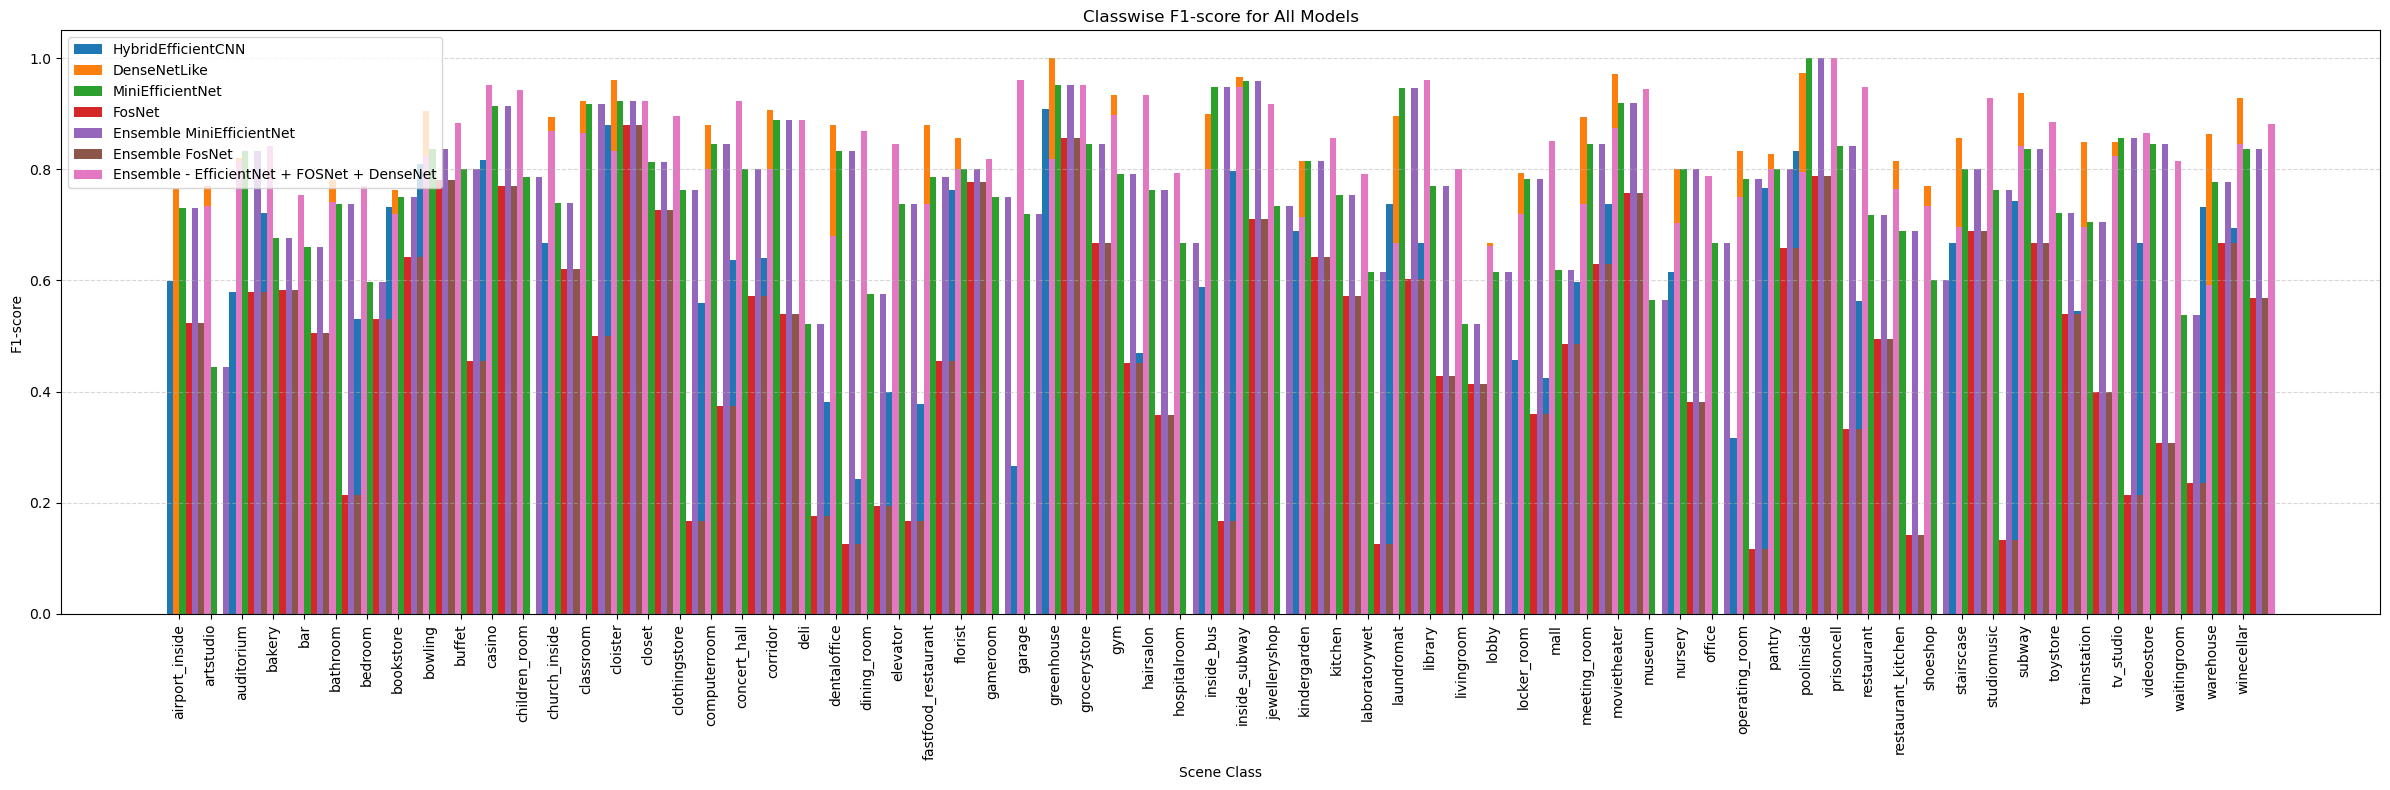

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names
classes = labelNames
num_classes = len(classes)
x = np.arange(num_classes)
width = 0.2  # width of each bar group

# Plotting
metrics = ["precision", "recall", "f1-score"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # blue, orange, green

for metric in metrics:
    plt.figure(figsize=(24, 8))
    for i, (model_name, report) in enumerate(models_result.items()):
        scores = [report[cls][metric] for cls in classes if cls in report]
        offset = (i - 1.5) * width
        plt.bar(x + offset, scores, width=width, label=model_name)

    plt.title(f"Classwise {metric.capitalize()} for All Models")
    plt.xticks(ticks=x, labels=classes, rotation=90)
    plt.xlabel("Scene Class")
    plt.ylabel(metric.capitalize())
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
# from sklearn.utils.class_weight import compute_class_weight

# trainEncodedLabels = [labelToIndex[label] for _, label in trainData]

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(trainEncodedLabels),
#     y=trainEncodedLabels
# )


# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
# criterion = nn.CrossEntropyLoss(
#     weight=class_weights,
#     label_smoothing=0.1
# )

In [23]:
# # model1
# def evaluateCNNModel(model, dataLoader, criterion):
#     model.eval()
#     totalLoss, correct, total = 0.0, 0, 0

#     with torch.no_grad():
#         for images, labels in dataLoader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             loss = criterion(outputs, labels)

#             totalLoss += loss.item()
#             _, preds = torch.max(outputs, 1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#     avgLoss = totalLoss / len(dataLoader)
#     accuracy = correct / total
#     return avgLoss, accuracy

# model1.load_state_dict(torch.load("project_HybridCNNSE_sarayusi_vishalim.pth", map_location=torch.device('cpu') ))
# testLoss, testAcc = evaluateCNNModel(model1, testLoader, criterion)

# allLabels, allPreds = [], []
# model1.eval()
# with torch.no_grad():
#     for images, labels in testLoader:
#         images = images.to(device)
#         outputs = model1(images)
#         _, preds = outputs.max(1)
#         allLabels.extend(labels.cpu().numpy())
#         allPreds.extend(preds.cpu().numpy())

# model1_report = classification_report(allLabels, allPreds, target_names=labelNames)

In [24]:
# print(model1_report)

In [25]:
# # model2

# def evaluateModel(model, dataLoader, criterion):
#     model.eval()
#     totalLoss, correct, total = 0.0, 0, 0

#     with torch.no_grad():
#         for images, labels in dataLoader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             loss = criterion(outputs, labels)

#             totalLoss += loss.item()
#             _, preds = torch.max(outputs, 1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#     avgLoss = totalLoss / len(dataLoader)
#     accuracy = correct / total
#     return avgLoss, accuracy

# model2.load_state_dict(torch.load("project_DenseNet_sarayusi_vishalim.pth", map_location=torch.device('cpu')))
# testLoss, testAcc = evaluateModel(model2, testLoader, criterion)
# # print(f"Test Accuracy: {testAcc*100:.4f} Test Loss: {testLoss:.4f}")

# allLabels, allPreds = [], []
# model2.eval()
# with torch.no_grad():
#     for images, labels in testLoader:
#         images = images.to(device)
#         outputs = model2(images)
#         _, preds = outputs.max(1)
#         allLabels.extend(labels.cpu().numpy())
#         allPreds.extend(preds.cpu().numpy())

# # cm = confusion_matrix(allLabels, allPreds)
# # sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
# # plt.xlabel("Predicted")
# # plt.ylabel("True")
# # plt.title("Confusion Matrix")
# # plt.show()

# # print(classification_report(allLabels, allPreds, target_names=classNames))


# model2_report = classification_report(allLabels, allPreds, target_names=labelNames)

In [26]:
# print(model2_report)

In [27]:
# # model 3

# def evaluate_on_test(model, test_loader, class_names):
#     model.eval()
#     y_true = []
#     y_pred = []

#     with torch.no_grad():
#         for images, labels in test_loader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             _, preds = torch.max(outputs, 1)
#             y_true.extend(labels.cpu().numpy())
#             y_pred.extend(preds.cpu().numpy())

#     # Confusion matrix
#     cm = confusion_matrix(y_true, y_pred)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
#     fig, ax = plt.subplots(figsize=(12, 12))
#     disp.plot(xticks_rotation=90, ax=ax, cmap='Blues', colorbar=False)
#     plt.title("Confusion Matrix")
#     plt.show()

#     # Classification report
#     report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
#     df_report = pd.DataFrame(report).transpose()
#     display(df_report.round(3))  # Show precision, recall, f1-score per class
    